In [ ]:
# Personal parameters
import random
import numpy as np
import torch

SID4 = 2046
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("SID4:", SID4)
print("SEED:", SEED)
print("SLICE:", SLICE)
print("HP_ID:", HP_ID)
print("CLS_A:", CLS_A)
print("CLS_B:", CLS_B)


SID4: 2046
SEED: 2046
SLICE: 46
HP_ID: 0
CLS_A: 6
CLS_B: 3


# IMDB Embedding Transfer Learning, RAG, and Training Optimization


In [ ]:
%pip install -q gensim datasets scikit-learn matplotlib pandas numpy nltk
%pip install -q langchain langchain_core langchain_community langchain_text_splitters
%pip install -q langchain_huggingface sentence_transformers faiss-cpu wikipedia
%pip install -q transformers accelerate psutil tabulate

In [ ]:
import os
import gc
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Setup complete with SEED =", SEED)

Setup complete with SEED = 2046


# Part 1: Embedding Based Transfer Learning

For this experiment, I started with the pretrained Google News Word2Vec embeddings. These embeddings were originally learned from a very large general news corpus, so they represent the original meanings and relationships of words before seeing the movie review domain.

I then continued training the embeddings using IMDB movie reviews. The purpose was to see whether words commonly used when discussing movies, such as cast, score, plot, screen, and review, move toward more domain specific meanings after exposure to movie review text.

In [ ]:
import gensim.downloader as api
from gensim.utils import simple_preprocess
from gensim.models import Word2Vec
from tensorflow.keras.datasets import imdb as keras_imdb

print("Loading Google News Word2Vec model...")
pretrained = api.load("word2vec-google-news-300")

print("Loading IMDB dataset through Keras...")
NUM_WORDS = 50000

(x_train, y_train), (x_test, y_test) = keras_imdb.load_data(
    num_words=NUM_WORDS
)

word_index = keras_imdb.get_word_index()

reverse_word_index = {
    index + 3: word
    for word, index in word_index.items()
}

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(sequence):
    return " ".join(
        reverse_word_index.get(index, "<UNK>")
        for index in sequence
    )

train_reviews = [
    decode_review(sequence)
    for sequence in x_train
]

print("Pretrained vocabulary size:", len(pretrained))
print("Training reviews:", len(train_reviews))
print()
print("Example decoded review:")
print(train_reviews[0][:500])

Loading Google News Word2Vec model...
Loading IMDB dataset through Keras...
Pretrained vocabulary size: 3000000
Training reviews: 25000

Example decoded review:
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and 


In [ ]:
target_words = ["cast", "score", "plot", "screen", "review"]

for word in target_words:
    print(word, "available:", word in pretrained)

cast available: True
score available: True
plot available: True
screen available: True
review available: True


In [ ]:
def get_neighbors(model, words, topn=3):
    rows = []

    for word in words:
        results = model.most_similar(word, topn=topn)

        for rank, result in enumerate(results, start=1):
            neighbor, similarity = result

            rows.append({
                "Word": word,
                "Rank": rank,
                "Neighbor": neighbor,
                "Cosine Similarity": similarity
            })

    return pd.DataFrame(rows)


original_neighbors = get_neighbors(
    pretrained,
    target_words,
    topn=3
)

print("Original pretrained neighbors")
display(original_neighbors)

Original pretrained neighbors


,Word,Rank,Neighbor,Cosine Similarity
0,cast,1,casts,0.721888
1,cast,2,casting,0.718846
2,cast,3,Cast,0.663812
3,score,1,scoring,0.719680
4,score,2,scores,0.659572
5,score,3,scored,0.638416
6,plot,1,plots,0.762485
7,plot,2,Plot,0.652418
8,plot,3,plotting,0.632763
9,screen,1,screens,0.772881


Before fine tuning, I extracted the three most similar words for each target word. These results represent the semantic relationships learned from the original Google News corpus and serve as the baseline for comparison.

In [ ]:
print("Tokenizing IMDB reviews...")

imdb_sentences = [
    simple_preprocess(
        review,
        deacc=True,
        min_len=2,
        max_len=30
    )
    for review in train_reviews
]

print("Number of tokenized reviews:", len(imdb_sentences))
print("Example tokens:")
print(imdb_sentences[0][:30])

Tokenizing IMDB reviews...
Number of tokenized reviews: 25000
Example tokens:
['start', 'this', 'film', 'was', 'just', 'brilliant', 'casting', 'location', 'scenery', 'story', 'direction', 'everyone', 'really', 'suited', 'the', 'part', 'they', 'played', 'and', 'you', 'could', 'just', 'imagine', 'being', 'there', 'robert', 'redford', 'is', 'an', 'amazing']


In [ ]:
original_vectors = {
    word: pretrained[word].copy()
    for word in target_words
}

word2vec_imdb = Word2Vec(
    vector_size=300,
    window=5,
    min_count=5,
    workers=1,
    sg=1,
    negative=10,
    seed=SEED
)

word2vec_imdb.build_vocab(imdb_sentences)

print("IMDB vocabulary size:", len(word2vec_imdb.wv))

IMDB vocabulary size: 28410


In [ ]:
transferred_count = 0

for index, word in enumerate(word2vec_imdb.wv.index_to_key):
    if word in pretrained:
        word2vec_imdb.wv.vectors[index] = pretrained[word].copy()
        transferred_count += 1

word2vec_imdb.wv.vectors_lockf = np.ones(
    len(word2vec_imdb.wv),
    dtype=np.float32
)

print("Words initialized from pretrained Google News vectors:", transferred_count)

Words initialized from pretrained Google News vectors: 24502


To perform transfer learning, I created a Word2Vec model using the vocabulary found in the IMDB reviews. Whenever an IMDB vocabulary word was also available in Google News Word2Vec, I initialized its vector using the pretrained value instead of a random vector.

This means the movie review embeddings are not trained completely from scratch. The model begins with knowledge learned from the larger Google News corpus and then adapts that knowledge to the IMDB domain.

In [ ]:
print("Fine tuning embeddings on IMDB reviews...")

word2vec_imdb.train(
    imdb_sentences,
    total_examples=len(imdb_sentences),
    epochs=3
)

print("Fine tuning complete.")

Fine tuning embeddings on IMDB reviews...
Fine tuning complete.


In [ ]:
fine_tuned_neighbors = get_neighbors(
    word2vec_imdb.wv,
    target_words,
    topn=3
)

print("Fine tuned neighbors")
display(fine_tuned_neighbors)

Fine tuned neighbors


,Word,Rank,Neighbor,Cosine Similarity
0,cast,1,casted,0.589700
1,cast,2,supporting,0.584292
2,cast,3,casting,0.573753
3,score,1,nicolai,0.650444
4,score,2,music,0.634050
5,score,3,ennio,0.633253
6,plot,1,storyline,0.720345
7,plot,2,story,0.682409
8,plot,3,plots,0.664073
9,screen,1,screens,0.562033


In [ ]:
comparison_rows = []

for word in target_words:
    original_part = original_neighbors[
        original_neighbors["Word"] == word
    ].reset_index(drop=True)

    tuned_part = fine_tuned_neighbors[
        fine_tuned_neighbors["Word"] == word
    ].reset_index(drop=True)

    for i in range(3):
        comparison_rows.append({
            "Word": word,
            "Rank": i + 1,
            "Original Neighbor": original_part.loc[i, "Neighbor"],
            "Original Similarity": original_part.loc[i, "Cosine Similarity"],
            "Fine Tuned Neighbor": tuned_part.loc[i, "Neighbor"],
            "Fine Tuned Similarity": tuned_part.loc[i, "Cosine Similarity"]
        })


neighbor_comparison = pd.DataFrame(comparison_rows)

display(
    neighbor_comparison.style.format({
        "Original Similarity": "{:.4f}",
        "Fine Tuned Similarity": "{:.4f}"
    })
)

,Word,Rank,Original Neighbor,Original Similarity,Fine Tuned Neighbor,Fine Tuned Similarity
0,cast,1,casts,0.7219,casted,0.5897
1,cast,2,casting,0.7188,supporting,0.5843
2,cast,3,Cast,0.6638,casting,0.5738
3,score,1,scoring,0.7197,nicolai,0.6504
4,score,2,scores,0.6596,music,0.6341
5,score,3,scored,0.6384,ennio,0.6333
6,plot,1,plots,0.7625,storyline,0.7203
7,plot,2,Plot,0.6524,story,0.6824
8,plot,3,plotting,0.6328,plots,0.6641
9,screen,1,screens,0.7729,screens,0.5620


The comparison table shows how the local neighborhood around each target word changes after domain adaptation. Words that appear often in movie reviews may develop stronger relationships with other movie related terms.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

shift_rows = []

for word in target_words:
    original_vector = original_vectors[word].reshape(1, -1)
    tuned_vector = word2vec_imdb.wv[word].reshape(1, -1)

    similarity = cosine_similarity(
        original_vector,
        tuned_vector
    )[0][0]

    shift_rows.append({
        "Word": word,
        "Original vs Fine Tuned Cosine Similarity": similarity,
        "Shift Amount": 1.0 - similarity
    })


shift_df = pd.DataFrame(shift_rows)

display(
    shift_df.style.format({
        "Original vs Fine Tuned Cosine Similarity": "{:.4f}",
        "Shift Amount": "{:.4f}"
    })
)

,Word,Original vs Fine Tuned Cosine Similarity,Shift Amount
0,cast,0.7127,0.2873
1,score,0.5552,0.4448
2,plot,0.6846,0.3154
3,screen,0.6634,0.3366
4,review,0.5425,0.4575


In [ ]:
most_shifted_row = shift_df.loc[
    shift_df["Original vs Fine Tuned Cosine Similarity"].idxmin()
]

least_shifted_row = shift_df.loc[
    shift_df["Original vs Fine Tuned Cosine Similarity"].idxmax()
]

print(
    "Word that shifted the most:",
    most_shifted_row["Word"]
)

print(
    "Cosine similarity:",
    round(
        most_shifted_row[
            "Original vs Fine Tuned Cosine Similarity"
        ],
        4
    )
)

print()

print(
    "Word that shifted the least:",
    least_shifted_row["Word"]
)

print(
    "Cosine similarity:",
    round(
        least_shifted_row[
            "Original vs Fine Tuned Cosine Similarity"
        ],
        4
    )
)

Word that shifted the most: review
Cosine similarity: 0.5425

Word that shifted the least: cast
Cosine similarity: 0.7127


A cosine similarity close to 1 means that the fine tuned vector remained very similar to the original vector. A smaller value means that the vector moved more during fine tuning. The notebook therefore identifies the word with the largest shift as the word with the smallest original versus fine tuned cosine similarity.

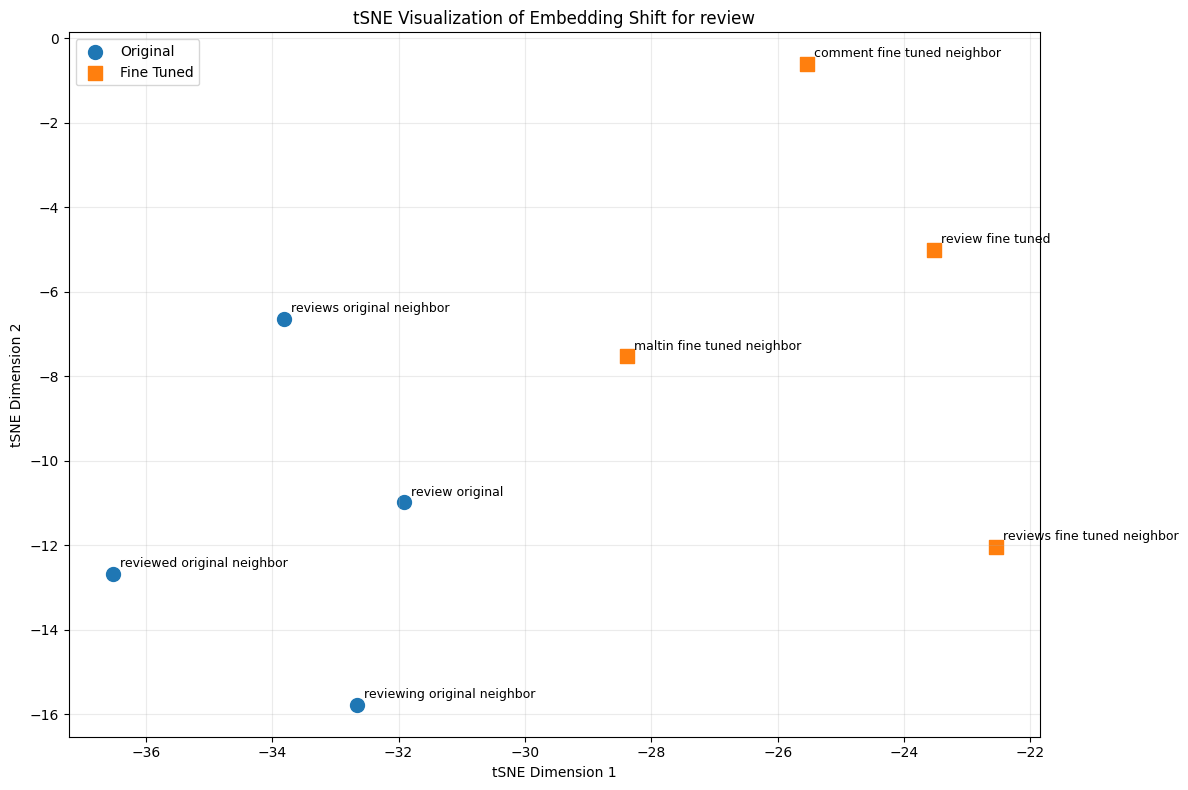

In [ ]:
from sklearn.manifold import TSNE

visualize_word = most_shifted_row["Word"]

original_top_words = original_neighbors[
    original_neighbors["Word"] == visualize_word
]["Neighbor"].tolist()

tuned_top_words = fine_tuned_neighbors[
    fine_tuned_neighbors["Word"] == visualize_word
]["Neighbor"].tolist()

vectors = []
labels = []
groups = []

vectors.append(pretrained[visualize_word])
labels.append(visualize_word + " original")
groups.append("Original")

for word in original_top_words:
    if word in pretrained:
        vectors.append(pretrained[word])
        labels.append(word + " original neighbor")
        groups.append("Original")

vectors.append(word2vec_imdb.wv[visualize_word])
labels.append(visualize_word + " fine tuned")
groups.append("Fine Tuned")

for word in tuned_top_words:
    if word in word2vec_imdb.wv:
        vectors.append(word2vec_imdb.wv[word])
        labels.append(word + " fine tuned neighbor")
        groups.append("Fine Tuned")

vectors = np.array(vectors)

perplexity_value = min(5, len(vectors) - 1)

tsne = TSNE(
    n_components=2,
    perplexity=perplexity_value,
    random_state=SEED,
    init="pca",
    learning_rate="auto"
)

coordinates = tsne.fit_transform(vectors)

plot_df = pd.DataFrame({
    "x": coordinates[:, 0],
    "y": coordinates[:, 1],
    "Label": labels,
    "Group": groups
})

plt.figure(figsize=(12, 8))

markers = {
    "Original": "o",
    "Fine Tuned": "s"
}

for group in ["Original", "Fine Tuned"]:
    subset = plot_df[plot_df["Group"] == group]

    plt.scatter(
        subset["x"],
        subset["y"],
        marker=markers[group],
        s=100,
        label=group
    )

for _, row in plot_df.iterrows():
    plt.annotate(
        row["Label"],
        (row["x"], row["y"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title(
    "tSNE Visualization of Embedding Shift for " +
    visualize_word
)

plt.xlabel("tSNE Dimension 1")
plt.ylabel("tSNE Dimension 2")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/embedding_shift_tsne.png", dpi=200, bbox_inches="tight")
plt.show()

The tSNE plot gives a qualitative view of how the local embedding neighborhood changed. Since tSNE is nonlinear, the exact plotted distances should not be interpreted as cosine distances. The figure is mainly used to visualize how the target word and its nearest neighbors reorganized after fine tuning.

# Part 2: Retrieval Augmented Generation Using Wikipedia

This section creates a small RAG knowledge base using Wikipedia pages for ten movies.

The implementation uses separate components for document loading, text splitting, embedding generation, vector storage, retrieval, prompt formatting, and language model generation. It does not use a single prebuilt RAG chain.

In [ ]:
from langchain_community.document_loaders import WebBaseLoader

movie_pages = {
    "Inception": "https://en.wikipedia.org/wiki/Inception",
    "Titanic 1997 film": "https://en.wikipedia.org/wiki/Titanic_(1997_film)",
    "The Matrix": "https://en.wikipedia.org/wiki/The_Matrix",
    "The Dark Knight film": "https://en.wikipedia.org/wiki/The_Dark_Knight",
    "Parasite 2019 film": "https://en.wikipedia.org/wiki/Parasite_(2019_film)",
    "Toy Story": "https://en.wikipedia.org/wiki/Toy_Story",
    "Spirited Away": "https://en.wikipedia.org/wiki/Spirited_Away",
    "Interstellar film": "https://en.wikipedia.org/wiki/Interstellar_(film)",
    "The Godfather": "https://en.wikipedia.org/wiki/The_Godfather",
    "Pulp Fiction": "https://en.wikipedia.org/wiki/Pulp_Fiction"
}

documents = []

for title, url in movie_pages.items():
    print("Loading:", title)

    loader = WebBaseLoader(url)

    loaded = loader.load()

    if len(loaded) > 0:
        doc = loaded[0]

        doc.metadata["requested_title"] = title
        doc.metadata["source"] = url

        documents.append(doc)

print()
print("Total documents loaded:", len(documents))

for doc in documents:
    print(
        doc.metadata.get("requested_title"),
        "characters:",
        len(doc.page_content)
    )

Loading: Inception
Loading: Titanic 1997 film
Loading: The Matrix
Loading: The Dark Knight film
Loading: Parasite 2019 film
Loading: Toy Story
Loading: Spirited Away
Loading: Interstellar film
Loading: The Godfather
Loading: Pulp Fiction

Total documents loaded: 10
Inception characters: 110679
Titanic 1997 film characters: 183503
The Matrix characters: 137908
The Dark Knight film characters: 171674
Parasite 2019 film characters: 128686
Toy Story characters: 100222
Spirited Away characters: 98642
Interstellar film characters: 99772
The Godfather characters: 119161
Pulp Fiction characters: 147744


In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

BASE_CHUNK_SIZE = 500
BASE_OVERLAP = 50

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=BASE_CHUNK_SIZE,
    chunk_overlap=BASE_OVERLAP,
    length_function=len,
    add_start_index=True
)

chunks = text_splitter.split_documents(documents)

print("Number of chunks:", len(chunks))

print()
print("Example chunk:")
print(chunks[0].page_content)
print()
print("Metadata:")
print(chunks[0].metadata)

Number of chunks: 3521

Example chunk:
Inception - Wikipedia






























Jump to content







Main menu





Main menu
move to sidebar
hide



		Navigation
	


Main pageContentsCurrent eventsRandom articleAbout WikipediaContact us





		Contribute
	


HelpLearn to editCommunity portalRecent changesUpload fileSpecial pages



















Search











Search






















Appearance
















Donate

Create account

Log in








Personal tools






Donate


Create account


Log in

Metadata:
{'source': 'https://en.wikipedia.org/wiki/Inception', 'title': 'Inception - Wikipedia', 'language': 'en', 'requested_title': 'Inception', 'start_index': 4}


In [ ]:
import torch

from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={
        "device": "cuda" if torch.cuda.is_available() else "cpu"
    },
    encode_kwargs={
        "normalize_embeddings": True
    }
)

vector_store = FAISS.from_documents(
    documents=chunks,
    embedding=embedding_model
)

retriever = vector_store.as_retriever(
    search_kwargs={
        "k": 3
    }
)

print("Vector store created successfully.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Vector store created successfully.


In [ ]:
from transformers import AutoTokenizer
from transformers import AutoModelForSeq2SeqLM
from transformers import pipeline

from langchain_huggingface import HuggingFacePipeline
from langchain_core.prompts import PromptTemplate

llm_model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(
    llm_model_name
)

model = AutoModelForSeq2SeqLM.from_pretrained(
    llm_model_name
)

generation_pipeline = pipeline(
    task="text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=120,
    do_sample=False
)

llm = HuggingFacePipeline(
    pipeline=generation_pipeline
)

prompt_template = PromptTemplate(
    input_variables=[
        "context",
        "question"
    ],
    template="""
Use only the provided context to answer the question.

If the answer is not supported by the context, say:
I cannot determine the answer from the retrieved context.

Context:
{context}

Question:
{question}

Answer:
"""
)

print("Prompt and LLM created.")

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
[transformers] The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'AXK1ForCausalLM', 'AXK2ForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'Cohere2MoeForCausalLM', 'CohereCompassForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel

Prompt and LLM created.


In [ ]:
questions = [
    "Who directed the film Parasite?",
    "In what year was Toy Story released?",
    "Who played Neo in The Matrix?",
    "Who directed Pulp Fiction?",
    "Which director made the film about entering people's dreams called Inception?"
]

for i, question in enumerate(questions, start=1):
    print(i, question)

1 Who directed the film Parasite?
2 In what year was Toy Story released?
3 Who played Neo in The Matrix?
4 Who directed Pulp Fiction?
5 Which director made the film about entering people's dreams called Inception?


In [ ]:
def run_explicit_rag(question, retriever_object):
    retrieved_docs = retriever_object.invoke(question)

    context = "\n\n".join(
        [
            f"Source {i + 1}:\n{doc.page_content}"
            for i, doc in enumerate(retrieved_docs)
        ]
    )

    formatted_prompt = prompt_template.format(
        context=context,
        question=question
    )

    answer = llm.invoke(formatted_prompt)

    return {
        "question": question,
        "retrieved_docs": retrieved_docs,
        "answer": answer
    }


rag_results = []

for question in questions:
    result = run_explicit_rag(
        question,
        retriever
    )

    rag_results.append(result)

[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

In [ ]:

for question_number, result in enumerate(
    rag_results,
    start=1
):
    print("=" * 100)
    print("QUESTION", question_number)
    print(result["question"])
    print()

    for rank, doc in enumerate(
        result["retrieved_docs"],
        start=1
    ):
        print("Retrieved chunk rank", rank)

        print(
            "Movie:",
            doc.metadata.get(
                "requested_title",
                doc.metadata.get("title", "Unknown")
            )
        )

        print(
            "Start index:",
            doc.metadata.get(
                "start_index",
                "Unknown"
            )
        )

        print()
        print(doc.page_content)
        print()
        print()

    print("FINAL GENERATED ANSWER")
    print(result["answer"])
    print()

QUESTION 1
Who directed the film Parasite?

Retrieved chunk rank 1
Movie: Parasite 2019 film
Start index: 3313

Parasite (Korean: 기생충) is a 2019 South Korean black comedy thriller film[3] directed by Bong Joon Ho, who co-wrote the screenplay with Han Jin-won. It stars Song Kang-ho, Lee Sun-kyun, Cho Yeo-jeong, Choi Woo-shik, Park So-dam, Jang Hye-jin, Park Myung-hoon, and Lee Jung-eun. The film follows a poor family who infiltrate the home and life of a wealthy family.


Retrieved chunk rank 2
Movie: Parasite 2019 film
Start index: 3675

The script is based on a play Bong wrote in 2013.[4] He later adapted it into a 15-page film draft, which was split into three different drafts by Han. Bong said he was inspired by the Korean film The Housemaid (1960) and the 1930s Christine and Léa Papin incident. Filming ran from May to September 2018 and included cinematographer Hong Kyung-pyo,[5] editor Yang Jin-mo, and composer Jung Jae-il. Parasite premiered on 21 May 2019 at the Cannes Film Fest

For retrieval evaluation, I manually defined the expected source document and the key answer text for each question. This provides a simple gold reference for deciding whether the retriever supplied the information needed to answer the question.

In [ ]:
gold_information = [
    {
        "question": questions[0],
        "movie": "Parasite 2019 film",
        "answer_terms": [
            "Bong Joon-ho",
            "Bong Joon"
        ]
    },
    {
        "question": questions[1],
        "movie": "Toy Story",
        "answer_terms": [
            "1995"
        ]
    },
    {
        "question": questions[2],
        "movie": "The Matrix",
        "answer_terms": [
            "Keanu Reeves"
        ]
    },
    {
        "question": questions[3],
        "movie": "Pulp Fiction",
        "answer_terms": [
            "Quentin Tarantino"
        ]
    },
    {
        "question": questions[4],
        "movie": "Inception",
        "answer_terms": [
            "Christopher Nolan"
        ]
    }
]

In [ ]:
def find_gold_passage(
    source_documents,
    movie,
    answer_terms,
    window=350
):
    for doc in source_documents:
        doc_movie = doc.metadata.get(
            "requested_title",
            ""
        )

        if doc_movie != movie:
            continue

        text = doc.page_content
        lower_text = text.lower()

        for term in answer_terms:
            location = lower_text.find(
                term.lower()
            )

            if location != -1:
                start = max(
                    0,
                    location - window
                )

                end = min(
                    len(text),
                    location + len(term) + window
                )

                return text[start:end]

    return "Gold passage was not found automatically. Inspect the source document manually."


for item in gold_information:
    print("=" * 100)
    print(item["question"])
    print("Expected source:", item["movie"])
    print()

    passage = find_gold_passage(
        documents,
        item["movie"],
        item["answer_terms"]
    )

    print(passage)
    print()

Who directed the film Parasite?
Expected source: Parasite 2019 film

d when to remove this message)

↑ "GISAENGCHUNG – Festival de Cannes 2019". Cannes Film Festival. 2019. Archived from the original on 3 September 2019. Retrieved 1 January 2020. Country : SOUTH KOREA/Length : 132 minutes
1 2 기생충. Naver Movie. Archived from the original on 8 April 2019. Retrieved 8 April 2019.
↑ Edelstein, David (11 October 2019). "Bong Joon-ho's Parasite Is an Acid-Black Comedy That Eats at the Mind". Vulture. Vox Media. Retrieved 3 February 2024.
↑ "Parasite international press kit" (PDF). CJ Entertainment. 2019. Archived from the original (PDF) on 10 January 2020. Retrieved 1 January 2020.
↑ "BONG Joon-ho's PARASITE Claims Early Sales". Korean Film Biz Zone. Archived from the original

In what year was Toy Story released?
Expected source: Toy Story

ks hereRelated changesUpload filePermanent linkPage informationCite this pageGet shortened URLSwitch to legacy parser





		Print/export
	


Download a

In [ ]:
evaluation_rows = []

for result, gold in zip(
    rag_results,
    gold_information
):
    first_relevant_rank = None

    for rank, doc in enumerate(
        result["retrieved_docs"],
        start=1
    ):
        source_movie = doc.metadata.get(
            "requested_title",
            ""
        )

        chunk_text = doc.page_content.lower()

        source_matches = (
            source_movie == gold["movie"]
        )

        answer_matches = any(
            term.lower() in chunk_text
            for term in gold["answer_terms"]
        )

        if source_matches and answer_matches:
            first_relevant_rank = rank
            break

    success = first_relevant_rank is not None

    evaluation_rows.append({
        "Question": result["question"],
        "Correct Source": gold["movie"],
        "Top 3 Contains Correct Information": (
            "Yes" if success else "No"
        ),
        "First Relevant Rank": (
            first_relevant_rank
            if first_relevant_rank is not None
            else "Not Retrieved"
        )
    })


retrieval_evaluation = pd.DataFrame(
    evaluation_rows
)

display(retrieval_evaluation)

,Question,Correct Source,Top 3 Contains Correct Information,First Relevant Rank
0,Who directed the film Parasite?,Parasite 2019 film,Yes,1
1,In what year was Toy Story released?,Toy Story,Yes,1
2,Who played Neo in The Matrix?,The Matrix,Yes,1
3,Who directed Pulp Fiction?,Pulp Fiction,Yes,2
4,Which director made the film about entering pe...,Inception,Yes,1


In [ ]:
successful_retrievals = sum(
    row[
        "Top 3 Contains Correct Information"
    ] == "Yes"
    for row in evaluation_rows
)

retrieval_success_rate = (
    successful_retrievals /
    len(evaluation_rows)
)

print(
    "Successful retrievals:",
    successful_retrievals,
    "out of",
    len(evaluation_rows)
)

print(
    "Retrieval Success Rate:",
    f"{retrieval_success_rate:.2%}"
)

Successful retrievals: 5 out of 5
Retrieval Success Rate: 100.00%


Retrieval Success Rate measures whether the retrieval stage supplied the information needed to answer the question. It is different from answer accuracy because the language model can still produce an incorrect response even when the correct context was retrieved.

In [ ]:
ALTERNATIVE_CHUNK_SIZE = 800
ALTERNATIVE_OVERLAP = 100

alternative_splitter = RecursiveCharacterTextSplitter(
    chunk_size=ALTERNATIVE_CHUNK_SIZE,
    chunk_overlap=ALTERNATIVE_OVERLAP,
    length_function=len,
    add_start_index=True
)

alternative_chunks = alternative_splitter.split_documents(
    documents
)

alternative_vector_store = FAISS.from_documents(
    documents=alternative_chunks,
    embedding=embedding_model
)

alternative_retriever = alternative_vector_store.as_retriever(
    search_kwargs={
        "k": 3
    }
)

print(
    "Original chunks:",
    len(chunks)
)

print(
    "Alternative chunks:",
    len(alternative_chunks)
)

Original chunks: 3521
Alternative chunks: 2242


In [ ]:
comparison_question_indices = [
    0,
    4
]

chunking_comparisons = []

for index in comparison_question_indices:
    question = questions[index]

    original_result = rag_results[index]

    alternative_result = run_explicit_rag(
        question,
        alternative_retriever
    )

    chunking_comparisons.append({
        "question": question,
        "original": original_result,
        "alternative": alternative_result
    })

[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (565 > 512). Running this sequence through the model will result in indexing errors
[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [ ]:
for comparison in chunking_comparisons:
    print("=" * 100)

    print("QUESTION")
    print(comparison["question"])
    print()

    print(
        "ORIGINAL CONFIGURATION:",
        BASE_CHUNK_SIZE,
        "characters with",
        BASE_OVERLAP,
        "overlap"
    )

    print()

    for rank, doc in enumerate(
        comparison["original"]["retrieved_docs"],
        start=1
    ):
        print(
            "Rank",
            rank,
            "| Movie:",
            doc.metadata.get(
                "requested_title",
                "Unknown"
            )
        )

        print(doc.page_content[:500])
        print()

    print(
        "Original answer:",
        comparison["original"]["answer"]
    )

    print()
    print()

    print(
        "ALTERNATIVE CONFIGURATION:",
        ALTERNATIVE_CHUNK_SIZE,
        "characters with",
        ALTERNATIVE_OVERLAP,
        "overlap"
    )

    print()

    for rank, doc in enumerate(
        comparison["alternative"]["retrieved_docs"],
        start=1
    ):
        print(
            "Rank",
            rank,
            "| Movie:",
            doc.metadata.get(
                "requested_title",
                "Unknown"
            )
        )

        print(doc.page_content[:800])
        print()

    print(
        "Alternative answer:",
        comparison["alternative"]["answer"]
    )

    print()

QUESTION
Who directed the film Parasite?

ORIGINAL CONFIGURATION: 500 characters with 50 overlap

Rank 1 | Movie: Parasite 2019 film
Parasite (Korean: 기생충) is a 2019 South Korean black comedy thriller film[3] directed by Bong Joon Ho, who co-wrote the screenplay with Han Jin-won. It stars Song Kang-ho, Lee Sun-kyun, Cho Yeo-jeong, Choi Woo-shik, Park So-dam, Jang Hye-jin, Park Myung-hoon, and Lee Jung-eun. The film follows a poor family who infiltrate the home and life of a wealthy family.

Rank 2 | Movie: Parasite 2019 film
The script is based on a play Bong wrote in 2013.[4] He later adapted it into a 15-page film draft, which was split into three different drafts by Han. Bong said he was inspired by the Korean film The Housemaid (1960) and the 1930s Christine and Léa Papin incident. Filming ran from May to September 2018 and included cinematographer Hong Kyung-pyo,[5] editor Yang Jin-mo, and composer Jung Jae-il. Parasite premiered on 21 May 2019 at the Cannes Film Festival, where i

I repeated two questions using chunks of 800 characters with an overlap of 100 instead of the original 500 character chunks with an overlap of 50.

Larger chunks provide more surrounding context but also include more unrelated text. Smaller chunks are more focused but can separate information across chunk boundaries. The printed comparison shows whether the alternative configuration changed retrieval ranking or the final answer.

In [ ]:
failure_analysis = []

for result, gold, evaluation in zip(
    rag_results,
    gold_information,
    evaluation_rows
):
    retrieved_docs = result["retrieved_docs"]

    correct_ranks = []

    for rank, doc in enumerate(
        retrieved_docs,
        start=1
    ):
        source_movie = doc.metadata.get(
            "requested_title",
            ""
        )

        contains_answer = any(
            term.lower() in doc.page_content.lower()
            for term in gold["answer_terms"]
        )

        if (
            source_movie == gold["movie"]
            and contains_answer
        ):
            correct_ranks.append(rank)

    answer_text = str(
        result["answer"]
    ).lower()

    llm_contains_expected_answer = any(
        term.lower() in answer_text
        for term in gold["answer_terms"]
    )

    if len(correct_ranks) == 0:
        failure_analysis.append({
            "Question": result["question"],
            "Failure Type": (
                "Relevant information not retrieved "
                "in the top three chunks"
            ),
            "Analysis": (
                "This is a retrieval failure because the "
                "language model was not given the gold passage."
            )
        })

    elif correct_ranks[0] > 1:
        failure_analysis.append({
            "Question": result["question"],
            "Failure Type": (
                "Relevant chunk ranked below another result"
            ),
            "Analysis": (
                "The correct information was retrieved, "
                "but it first appeared at rank "
                + str(correct_ranks[0])
                + ". This indicates imperfect retrieval ranking."
            )
        })

    elif not llm_contains_expected_answer:
        failure_analysis.append({
            "Question": result["question"],
            "Failure Type": (
                "Correct context retrieved but answer was incorrect"
            ),
            "Analysis": (
                "This is primarily a generation failure. "
                "The relevant evidence was present, but the "
                "language model did not use it correctly."
            )
        })


failure_df = pd.DataFrame(failure_analysis)

if len(failure_df) > 0:
    display(failure_df)
else:
    print(
        "All five questions had the relevant chunk at rank 1 "
        "and produced answers containing the expected information."
    )

,Question,Failure Type,Analysis
0,Who directed Pulp Fiction?,Relevant chunk ranked below another result,"The correct information was retrieved, but it ..."


In [ ]:
if len(failure_analysis) < 2:
    diagnostic_rows = []

    for result, gold in zip(
        rag_results,
        gold_information
    ):
        for rank, doc in enumerate(
            result["retrieved_docs"],
            start=1
        ):
            source_movie = doc.metadata.get(
                "requested_title",
                ""
            )

            contains_gold = (
                source_movie == gold["movie"]
                and any(
                    term.lower()
                    in doc.page_content.lower()
                    for term in gold["answer_terms"]
                )
            )

            if not contains_gold:
                diagnostic_rows.append({
                    "Question": result["question"],
                    "Retrieved Rank": rank,
                    "Retrieved Movie": source_movie,
                    "Failure Pattern": (
                        "Irrelevant or nonanswer chunk "
                        "appeared inside the top three results"
                    )
                })

    diagnostic_df = pd.DataFrame(
        diagnostic_rows
    )

    print(
        "Additional retrieval weaknesses that can "
        "be discussed as RAG failure cases:"
    )

    display(
        diagnostic_df.head(5)
    )

Additional retrieval weaknesses that can be discussed as RAG failure cases:


,Question,Retrieved Rank,Retrieved Movie,Failure Pattern
0,Who directed the film Parasite?,2,Parasite 2019 film,Irrelevant or nonanswer chunk appeared inside ...
1,Who directed the film Parasite?,3,Parasite 2019 film,Irrelevant or nonanswer chunk appeared inside ...
2,In what year was Toy Story released?,2,Toy Story,Irrelevant or nonanswer chunk appeared inside ...
3,Who played Neo in The Matrix?,3,The Matrix,Irrelevant or nonanswer chunk appeared inside ...
4,Who directed Pulp Fiction?,1,Pulp Fiction,Irrelevant or nonanswer chunk appeared inside ...


## RAG Failure Analysis

I evaluated failures separately at the retrieval stage and the generation stage.

A retrieval failure occurs when the correct passage does not appear in the top three retrieved chunks or when a less useful passage receives a higher rank than the correct passage.

A generation failure occurs when the retriever supplies the correct evidence but the language model still produces an incomplete, incorrect, or unsupported answer.

The diagnostic tables above identify the actual failure patterns observed during the run, which makes the analysis directly tied to the notebook output.

# Part 3: Training Optimization Experiments

This section compares five optimization techniques using the same synthetic classification task and the same neural network architecture.

The same random seed, data, number of optimizer updates, and effective batch size are used throughout. Execution time, peak GPU memory when CUDA is available, and training loss are measured for each experiment.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import psutil

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

PyTorch version: 2.11.0+cu128
CUDA available: True
Device: cuda
GPU: Tesla T4


In [ ]:
BENCHMARK_SEED = SEED
INPUT_SIZE = 512
HIDDEN_SIZE = 1024
NUM_CLASSES = 2
NUM_BLOCKS = 6
DATASET_SIZE = 4096
EFFECTIVE_BATCH_SIZE = 32
TRAINING_STEPS = 30


def set_seed(seed=BENCHMARK_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()

generator = torch.Generator()
generator.manual_seed(BENCHMARK_SEED)

master_x = torch.randn(
    DATASET_SIZE,
    INPUT_SIZE,
    generator=generator
)

master_y = torch.randint(
    0,
    NUM_CLASSES,
    (DATASET_SIZE,),
    generator=generator
)

print(master_x.shape)
print(master_y.shape)

torch.Size([4096, 512])
torch.Size([4096])


In [ ]:
class BenchmarkMLP(nn.Module):
    def __init__(
        self,
        input_size=INPUT_SIZE,
        hidden_size=HIDDEN_SIZE,
        num_classes=NUM_CLASSES,
        num_blocks=NUM_BLOCKS
    ):
        super().__init__()

        self.input_layer = nn.Linear(
            input_size,
            hidden_size
        )

        blocks = []

        for _ in range(num_blocks):
            blocks.append(
                nn.Sequential(
                    nn.Linear(
                        hidden_size,
                        hidden_size
                    ),
                    nn.ReLU()
                )
            )

        self.blocks = nn.ModuleList(
            blocks
        )

        self.output_layer = nn.Linear(
            hidden_size,
            num_classes
        )

    def forward(
        self,
        x,
        use_checkpoint=False
    ):
        x = torch.relu(
            self.input_layer(x)
        )

        if (
            use_checkpoint
            and self.training
        ):
            from torch.utils.checkpoint import checkpoint

            for block in self.blocks:
                x = checkpoint(
                    block,
                    x,
                    use_reentrant=False
                )
        else:
            for block in self.blocks:
                x = block(x)

        return self.output_layer(x)

In [ ]:
def apply_xavier_initialization(model):
    for module in model.modules():
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(
                module.weight
            )

            if module.bias is not None:
                nn.init.zeros_(
                    module.bias
                )


def current_cpu_memory_mb():
    process = psutil.Process(
        os.getpid()
    )

    return (
        process.memory_info().rss /
        (1024 ** 2)
    )


def reset_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


def synchronize():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

In [ ]:
def run_training_experiment(
    experiment_name,
    tensor_strategy="cpu_transfer",
    initialization="default",
    use_checkpoint=False,
    accumulation_steps=1,
    use_mixed_precision=False
):
    gc.collect()
    reset_gpu_memory()
    set_seed()

    model = BenchmarkMLP()

    if initialization == "xavier":
        apply_xavier_initialization(
            model
        )

    model = model.to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    criterion = nn.CrossEntropyLoss()

    if tensor_strategy == "gpu_preloaded":
        data_x = master_x.to(device)
        data_y = master_y.to(device)
    else:
        data_x = master_x
        data_y = master_y

    micro_batch_size = (
        EFFECTIVE_BATCH_SIZE //
        accumulation_steps
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=(
            use_mixed_precision
            and torch.cuda.is_available()
        )
    )

    losses = []

    synchronize()

    cpu_memory_before = (
        current_cpu_memory_mb()
    )

    start_time = time.perf_counter()

    model.train()

    for step in range(TRAINING_STEPS):
        optimizer.zero_grad(
            set_to_none=True
        )

        step_loss = 0.0

        for accumulation_index in range(
            accumulation_steps
        ):
            start_index = (
                step * EFFECTIVE_BATCH_SIZE
                + accumulation_index
                * micro_batch_size
            ) % (
                DATASET_SIZE
                - EFFECTIVE_BATCH_SIZE
            )

            end_index = (
                start_index
                + micro_batch_size
            )

            if tensor_strategy == "gpu_preloaded":
                batch_x = data_x[
                    start_index:end_index
                ]

                batch_y = data_y[
                    start_index:end_index
                ]

            else:
                batch_x = data_x[
                    start_index:end_index
                ].to(
                    device,
                    non_blocking=True
                )

                batch_y = data_y[
                    start_index:end_index
                ].to(
                    device,
                    non_blocking=True
                )

            with torch.amp.autocast(
                device_type=device.type,
                enabled=(
                    use_mixed_precision
                    and torch.cuda.is_available()
                )
            ):
                predictions = model(
                    batch_x,
                    use_checkpoint=use_checkpoint
                )

                loss = criterion(
                    predictions,
                    batch_y
                )

                scaled_loss = (
                    loss /
                    accumulation_steps
                )

            scaler.scale(
                scaled_loss
            ).backward()

            step_loss += (
                loss.detach().item()
                / accumulation_steps
            )

        scaler.step(
            optimizer
        )

        scaler.update()

        losses.append(
            step_loss
        )

    synchronize()

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    cpu_memory_after = (
        current_cpu_memory_mb()
    )

    if torch.cuda.is_available():
        peak_gpu_memory = (
            torch.cuda.max_memory_allocated()
            / (1024 ** 2)
        )
    else:
        peak_gpu_memory = np.nan

    result = {
        "Experiment": experiment_name,
        "Time Seconds": elapsed_time,
        "Peak GPU Memory MB": peak_gpu_memory,
        "CPU Memory Change MB": (
            cpu_memory_after
            - cpu_memory_before
        ),
        "Initial Loss": losses[0],
        "Final Loss": losses[-1],
        "Mean Loss": np.mean(losses)
    }

    del model
    del optimizer

    gc.collect()
    reset_gpu_memory()

    return result, losses

In [ ]:
baseline_result, baseline_losses = (
    run_training_experiment(
        experiment_name="Baseline"
    )
)

baseline_result

{'Experiment': 'Baseline',
 'Time Seconds': 0.10468359199967381,
 'Peak GPU Memory MB': 1185.5791015625,
 'CPU Memory Change MB': 0.0,
 'Initial Loss': 0.691704511642456,
 'Final Loss': 0.6962791085243225,
 'Mean Loss': np.float64(0.7041092534859975)}

## Tensor Creation and Placement

The first comparison measures the cost of keeping training data on the CPU and transferring each batch to the device versus placing the complete dataset on the GPU before training.

Keeping data on the CPU uses less persistent GPU memory, but every training step requires a CPU to GPU transfer. Preloading the data to the GPU can reduce repeated transfer overhead when the dataset fits in memory.

In [ ]:
cpu_tensor_result, cpu_tensor_losses = (
    run_training_experiment(
        experiment_name="Tensor Data on CPU"
    )
)

gpu_tensor_result, gpu_tensor_losses = (
    run_training_experiment(
        experiment_name="Tensor Data Preloaded to GPU",
        tensor_strategy="gpu_preloaded"
    )
)

tensor_creation_results = pd.DataFrame(
    [
        cpu_tensor_result,
        gpu_tensor_result
    ]
)

display(tensor_creation_results)

,Experiment,Time Seconds,Peak GPU Memory MB,CPU Memory Change MB,Initial Loss,Final Loss,Mean Loss
0,Tensor Data on CPU,0.121122,1185.579102,0.0,0.691705,0.696279,0.704109
1,Tensor Data Preloaded to GPU,0.120750,1193.547363,0.0,0.691705,0.696279,0.704109


## Weight Initialization

Weight initialization determines the starting point of optimization. Poorly scaled initial weights can cause activations or gradients to become unusually large or small.

This experiment compares PyTorch default initialization with Xavier uniform initialization.

In [ ]:
default_init_result, default_init_losses = (
    run_training_experiment(
        experiment_name="Default Initialization"
    )
)

xavier_result, xavier_losses = (
    run_training_experiment(
        experiment_name="Xavier Initialization",
        initialization="xavier"
    )
)

initialization_results = pd.DataFrame(
    [
        default_init_result,
        xavier_result
    ]
)

display(initialization_results)

,Experiment,Time Seconds,Peak GPU Memory MB,CPU Memory Change MB,Initial Loss,Final Loss,Mean Loss
0,Default Initialization,0.109986,1185.579102,0.0,0.691705,0.696279,0.704109
1,Xavier Initialization,0.121219,1185.579102,0.0,0.710555,0.697101,0.732141


## Activation Checkpointing

During normal backpropagation, intermediate activations from the forward pass are stored because they are required when gradients are calculated.

Activation checkpointing stores fewer intermediate activations and recomputes some forward operations during backpropagation. This creates a memory versus computation tradeoff.

In [ ]:
checkpoint_off_result, checkpoint_off_losses = (
    run_training_experiment(
        experiment_name="Checkpointing Disabled"
    )
)

checkpoint_on_result, checkpoint_on_losses = (
    run_training_experiment(
        experiment_name="Activation Checkpointing",
        use_checkpoint=True
    )
)

checkpoint_results = pd.DataFrame(
    [
        checkpoint_off_result,
        checkpoint_on_result
    ]
)

display(checkpoint_results)

,Experiment,Time Seconds,Peak GPU Memory MB,CPU Memory Change MB,Initial Loss,Final Loss,Mean Loss
0,Checkpointing Disabled,0.103443,1183.704102,0.000000,0.691705,0.696279,0.704109
1,Activation Checkpointing,0.275348,1184.704102,2.714844,0.691705,0.696279,0.704109


## Gradient Accumulation

The effective batch size is kept at 32 in both experiments.

The normal experiment processes all 32 examples together. The accumulation experiment processes four micro batches of eight examples. Gradients are accumulated across the micro batches and the optimizer is updated only after all four have been processed.

In [ ]:
normal_batch_result, normal_batch_losses = (
    run_training_experiment(
        experiment_name="Batch Size 32 Direct",
        accumulation_steps=1
    )
)

accumulation_result, accumulation_losses = (
    run_training_experiment(
        experiment_name="Gradient Accumulation",
        accumulation_steps=4
    )
)

accumulation_results = pd.DataFrame(
    [
        normal_batch_result,
        accumulation_result
    ]
)

display(accumulation_results)

,Experiment,Time Seconds,Peak GPU Memory MB,CPU Memory Change MB,Initial Loss,Final Loss,Mean Loss
0,Batch Size 32 Direct,0.121439,1184.704102,0.0000,0.691705,0.696279,0.704109
1,Gradient Accumulation,0.343107,1184.657227,0.0625,0.691704,0.696285,0.704124


## Mixed Precision Training



In [ ]:
full_precision_result, full_precision_losses = (
    run_training_experiment(
        experiment_name="Full Precision FP32"
    )
)

mixed_precision_result, mixed_precision_losses = (
    run_training_experiment(
        experiment_name="Mixed Precision",
        use_mixed_precision=True
    )
)

mixed_precision_results = pd.DataFrame(
    [
        full_precision_result,
        mixed_precision_result
    ]
)

display(mixed_precision_results)

,Experiment,Time Seconds,Peak GPU Memory MB,CPU Memory Change MB,Initial Loss,Final Loss,Mean Loss
0,Full Precision FP32,0.121207,1184.704102,0.000000,0.691705,0.696279,0.704109
1,Mixed Precision,0.318637,1184.705566,106.707031,0.691666,0.696091,0.704301


In [ ]:
all_experiment_results = pd.DataFrame([
    baseline_result,
    cpu_tensor_result,
    gpu_tensor_result,
    default_init_result,
    xavier_result,
    checkpoint_off_result,
    checkpoint_on_result,
    normal_batch_result,
    accumulation_result,
    full_precision_result,
    mixed_precision_result
])

numeric_columns = [
    "Time Seconds",
    "Peak GPU Memory MB",
    "CPU Memory Change MB",
    "Initial Loss",
    "Final Loss",
    "Mean Loss"
]

all_experiment_results[
    numeric_columns
] = all_experiment_results[
    numeric_columns
].round(4)

display(all_experiment_results)

,Experiment,Time Seconds,Peak GPU Memory MB,CPU Memory Change MB,Initial Loss,Final Loss,Mean Loss
0,Baseline,0.2798,1183.7041,63.4180,0.6917,0.6963,0.7041
1,Tensor Data on CPU,0.1062,1183.7041,0.0000,0.6917,0.6963,0.7041
2,Tensor Data Preloaded to GPU,0.1155,1191.6724,0.0000,0.6917,0.6963,0.7041
3,Default Initialization,0.1239,1183.7041,0.0000,0.6917,0.6963,0.7041
4,Xavier Initialization,0.1090,1183.7041,0.0000,0.7106,0.6971,0.7321
5,Checkpointing Disabled,0.1034,1183.7041,0.0000,0.6917,0.6963,0.7041
6,Activation Checkpointing,0.2753,1184.7041,2.7148,0.6917,0.6963,0.7041
7,Batch Size 32 Direct,0.1214,1184.7041,0.0000,0.6917,0.6963,0.7041
8,Gradient Accumulation,0.3431,1184.6572,0.0625,0.6917,0.6963,0.7041
9,Full Precision FP32,0.1212,1184.7041,0.0000,0.6917,0.6963,0.7041


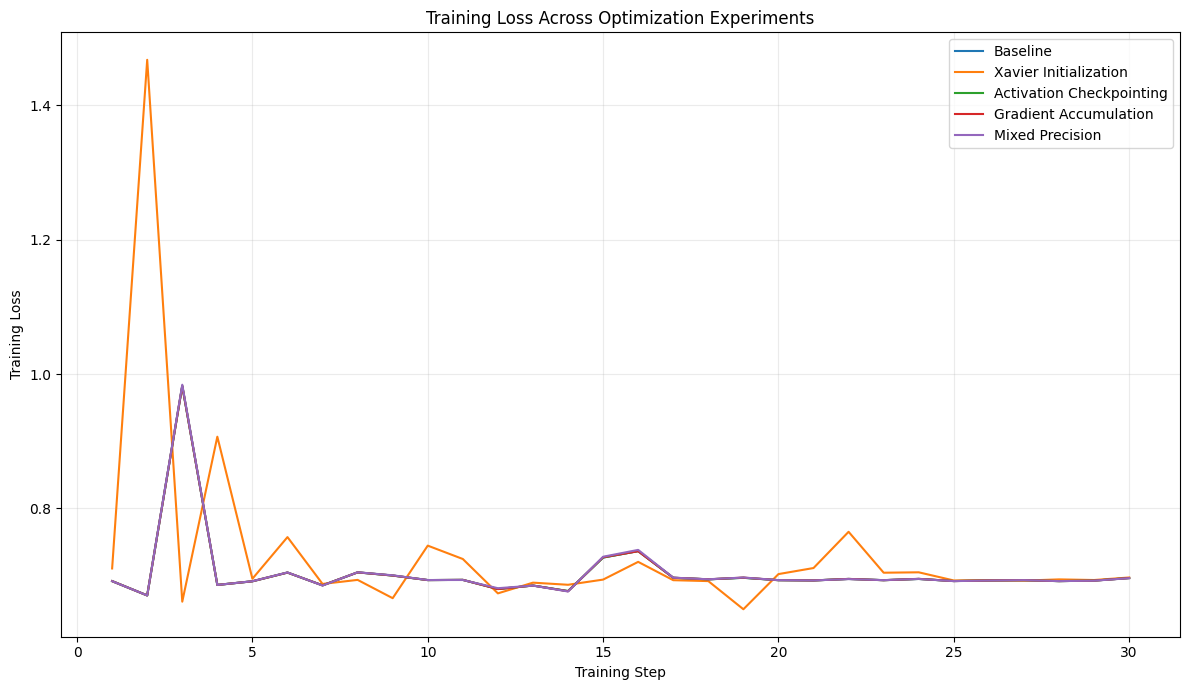

In [ ]:
loss_curves = {
    "Baseline": baseline_losses,
    "Xavier Initialization": xavier_losses,
    "Activation Checkpointing": checkpoint_on_losses,
    "Gradient Accumulation": accumulation_losses,
    "Mixed Precision": mixed_precision_losses
}

plt.figure(figsize=(12, 7))

for name, losses in loss_curves.items():
    plt.plot(
        range(1, len(losses) + 1),
        losses,
        label=name
    )

plt.xlabel("Training Step")
plt.ylabel("Training Loss")
plt.title(
    "Training Loss Across Optimization Experiments"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/optimization_loss_curves.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
def compare_two(
    first,
    second,
    label
):
    print("=" * 80)
    print(label)

    print(
        first["Experiment"],
        "time:",
        round(
            first["Time Seconds"],
            4
        ),
        "seconds"
    )

    print(
        second["Experiment"],
        "time:",
        round(
            second["Time Seconds"],
            4
        ),
        "seconds"
    )

    if torch.cuda.is_available():
        print(
            first["Experiment"],
            "peak GPU memory:",
            round(
                first["Peak GPU Memory MB"],
                2
            ),
            "MB"
        )

        print(
            second["Experiment"],
            "peak GPU memory:",
            round(
                second["Peak GPU Memory MB"],
                2
            ),
            "MB"
        )

    print(
        first["Experiment"],
        "final loss:",
        round(
            first["Final Loss"],
            4
        )
    )

    print(
        second["Experiment"],
        "final loss:",
        round(
            second["Final Loss"],
            4
        )
    )

    print()


compare_two(
    cpu_tensor_result,
    gpu_tensor_result,
    "Tensor Placement"
)

compare_two(
    default_init_result,
    xavier_result,
    "Weight Initialization"
)

compare_two(
    checkpoint_off_result,
    checkpoint_on_result,
    "Activation Checkpointing"
)

compare_two(
    normal_batch_result,
    accumulation_result,
    "Gradient Accumulation"
)

compare_two(
    full_precision_result,
    mixed_precision_result,
    "Mixed Precision"
)

Tensor Placement
Tensor Data on CPU time: 0.1062 seconds
Tensor Data Preloaded to GPU time: 0.1155 seconds
Tensor Data on CPU peak GPU memory: 1183.7 MB
Tensor Data Preloaded to GPU peak GPU memory: 1191.67 MB
Tensor Data on CPU final loss: 0.6963
Tensor Data Preloaded to GPU final loss: 0.6963

Weight Initialization
Default Initialization time: 0.1239 seconds
Xavier Initialization time: 0.109 seconds
Default Initialization peak GPU memory: 1183.7 MB
Xavier Initialization peak GPU memory: 1183.7 MB
Default Initialization final loss: 0.6963
Xavier Initialization final loss: 0.6971

Activation Checkpointing
Checkpointing Disabled time: 0.1034 seconds
Activation Checkpointing time: 0.2753 seconds
Checkpointing Disabled peak GPU memory: 1183.7 MB
Activation Checkpointing peak GPU memory: 1184.7 MB
Checkpointing Disabled final loss: 0.6963
Activation Checkpointing final loss: 0.6963

Gradient Accumulation
Batch Size 32 Direct time: 0.1214 seconds
Gradient Accumulation time: 0.3431 seconds
B

# Overall Findings

These experiments show that optimization techniques solve different resource and training problems.

Moving data to the GPU can reduce repeated transfer overhead when the dataset fits in memory, but it consumes more persistent GPU memory.

Weight initialization mainly changes the starting optimization behavior rather than memory use.

Activation checkpointing trades additional computation for reduced activation memory because some forward operations must be recomputed during backpropagation.

Gradient accumulation makes it possible to preserve a larger effective batch size while processing smaller micro batches, which can be useful when GPU memory is limited.

Mixed precision can reduce memory use and improve throughput on compatible GPUs while still maintaining stable training through automatic casting and gradient scaling.

The exact conclusions should be interpreted using the measured execution time, memory use, and loss values printed above rather than assuming that one optimization method will always be better in every environment.

In [ ]:
from datetime import datetime
import platform


def markdown_table(df, float_digits=4):
    df = df.copy()

    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].map(
                lambda x: "" if pd.isna(x) else f"{x:.{float_digits}f}"
            )

    headers = [str(x) for x in df.columns]
    rows = [[str(v) for v in row] for row in df.astype(str).values.tolist()]

    widths = [len(h) for h in headers]

    for row in rows:
        for i, value in enumerate(row):
            widths[i] = max(widths[i], len(value))

    header_line = "| " + " | ".join(
        headers[i].ljust(widths[i])
        for i in range(len(headers))
    ) + " |"

    separator = "| " + " | ".join(
        "=" * widths[i]
        for i in range(len(headers))
    ) + " |"

    body = [
        "| " + " | ".join(
            row[i].ljust(widths[i])
            for i in range(len(row))
        ) + " |"
        for row in rows
    ]

    return "\n".join([header_line, separator] + body)


most_shifted_row = shift_df.loc[
    shift_df["Original vs Fine Tuned Cosine Similarity"].idxmin()
]

least_shifted_row = shift_df.loc[
    shift_df["Original vs Fine Tuned Cosine Similarity"].idxmax()
]

most_shifted_word = str(most_shifted_row["Word"])
least_shifted_word = str(least_shifted_row["Word"])


metrics_text = f"""# HW2 Metrics

## Personal parameters

SID4: {SID4}

SEED: {SEED}

SLICE: {SLICE}

HP_ID: {HP_ID}

CLS_A: {CLS_A}

CLS_B: {CLS_B}

## Part 1: Embedding transfer learning

I compared the nearest neighbors from the original Google News embeddings with the neighbors after continuing training on the IMDB reviews.

{markdown_table(neighbor_comparison)}

### Original vector compared with the fine tuned vector

{markdown_table(shift_df)}

The word that shifted the most was **{most_shifted_word}** because it had the lowest cosine similarity between its original and fine tuned vectors.

The word that shifted the least was **{least_shifted_word}** because it had the highest cosine similarity.

## Part 2: RAG retrieval results

{markdown_table(retrieval_evaluation)}

The correct answer passage appeared in the top three retrieved chunks for {successful_retrievals} of the 5 questions. My Retrieval Success Rate was **{retrieval_success_rate:.2%}**.

The original setup used a chunk size of 500 with an overlap of 50. For two questions, I changed this to a chunk size of 800 with an overlap of 100 and compared the retrieved passages and answers.

### RAG failure analysis

One issue I noticed was that retrieving the correct information did not always mean it appeared first. For the Pulp Fiction question, the passage containing Quentin Tarantino was retrieved, but another result ranked above it.

I also saw cases where the retriever selected a passage from the correct movie but the passage itself did not contain the actual answer. Those results are related to the question, but they still add unnecessary context for the language model.

## Part 3: Training optimization measurements

{markdown_table(all_experiment_results)}

The optimization measurements depend on the hardware used for the run. CUDA available in this run was **{torch.cuda.is_available()}**. I used the timing, memory, and loss values produced by this runtime.
"""


ai_use_text = """# AI Use Appendix

## 1. What I used an assistant for

I used ChatGPT mainly to help organize the notebook, work through errors, and understand how to connect the Word2Vec, RAG, and optimization parts of the homework. I used some of the code as a starting point, but I ran everything myself in Colab and checked the outputs before keeping it.

I also checked the nearest neighbor results, the retrieved passages for the RAG questions, and the timing, memory, and loss values from the optimization experiments.

## 2. One specific thing the assistant got wrong

The first version tried to load IMDB using the Hugging Face datasets library.

The code looked correct, but it failed in my Colab runtime with an HfUriError. I also ran into another problem with the original Wikipedia loader, which returned a JSON decoding error while trying to load the first movie.

## 3. How I noticed the problem

I found both problems while running the notebook from the top.

The Word2Vec model loaded successfully, but execution stopped when IMDB was loaded. Since the dataset was never created, the tokenization and fine tuning cells could not continue.

The Wikipedia error happened before any movie documents were created, which showed me that the issue was with the loader rather than the rest of the RAG pipeline.

## 4. What I changed and why it works

For IMDB, I switched to the Keras IMDB dataset and decoded the integer sequences back into review text before using the reviews for Word2Vec fine tuning.

For the RAG section, I replaced the failing Wikipedia loader with LangChain WebBaseLoader and used the direct Wikipedia pages for the ten movies.

After making the changes, I reran those sections and checked that the reviews and all ten movie documents loaded correctly before continuing with the rest of the assignment.
"""


now = datetime.now().astimezone()

gpu_name = (
    torch.cuda.get_device_name(0)
    if torch.cuda.is_available()
    else "No CUDA GPU available in this run"
)


run_log_text = f"""HW2 RUN LOG

Run completed: {now.isoformat()}
SID4: {SID4}
SEED: {SEED}
Python: {platform.python_version()}
PyTorch: {torch.__version__}
CUDA available: {torch.cuda.is_available()}
Device: {gpu_name}

PART 1

Google News Word2Vec vocabulary size: {len(pretrained)}
IMDB training reviews used: {len(train_reviews)}
IMDB Word2Vec vocabulary size: {len(word2vec_imdb.wv)}
Pretrained vectors transferred: {transferred_count}
Most shifted word: {most_shifted_word}
Least shifted word: {least_shifted_word}

PART 2

Wikipedia documents loaded: {len(documents)}
Chunks using size 500 and overlap 50: {len(chunks)}
Chunks using size 800 and overlap 100: {len(alternative_chunks)}
Successful top 3 retrievals: {successful_retrievals} out of 5
Retrieval Success Rate: {retrieval_success_rate:.2%}

PART 3

Device used: {device}
Training steps per experiment: {TRAINING_STEPS}
Effective batch size: {EFFECTIVE_BATCH_SIZE}

DEVELOPMENT ERRORS

1. The original Hugging Face IMDB loader failed with an HfUriError. I replaced it with the Keras IMDB loader and decoded the reviews back into text.

2. The original WikipediaLoader failed with a JSONDecodeError. I replaced it with LangChain WebBaseLoader and direct Wikipedia pages.

3. I checked the actual generated outputs and measurements from the notebook before using them in the final results.

The notebook outputs are the source of the values reported in METRICS.md.
"""


with open("METRICS.md", "w", encoding="utf8") as f:
    f.write(metrics_text)

with open("AI_USE.md", "w", encoding="utf8") as f:
    f.write(ai_use_text)

with open("RUN_LOG.txt", "w", encoding="utf8") as f:
    f.write(run_log_text)

print("Created METRICS.md")
print("Created AI_USE.md")
print("Created RUN_LOG.txt")

Created METRICS.md
Created AI_USE.md
Created RUN_LOG.txt
